In [19]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg
import ast
import colorsys

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
MIX_COLOR = '#C07B7E'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [20]:
stim_df = pd.read_csv(os.path.join('..','..','Source Data Files',"Figure 3g control.csv"))

In [21]:
stim_df

,Unnamed: 0,session,clust,accuracy,NCR_ratio,learning_phase,animal
0,0,BS_108_1_AC.pickle,[14],0.551433,0.00,pre_expert,BS_108_1_AC
1,1,BS_108_1_AC.pickle,"[8, 9, 34, 35]",0.837250,0.00,pre_expert,BS_108_1_AC
2,2,BS_108_1_AC.pickle,"[8, 9, 14, 34]",0.853713,0.00,pre_expert,BS_108_1_AC
3,3,BS_108_1_AC.pickle,"[2, 8, 9, 34, 35]",0.831911,0.00,pre_expert,BS_108_1_AC
4,4,BS_108_1_AC.pickle,"[2, 8, 9, 34, 35]",0.831911,0.00,pre_expert,BS_108_1_AC
...,...,...,...,...,...,...,...
9270,9270,AE_312_8_opto_control_AC.pickle,"[14, 15, 35, 69, 77, 78, 84, 96, 118, 121, 153...",0.866514,0.45,post_expert,AE_312_8_opto_control_AC
9271,9271,AE_312_8_opto_control_AC.pickle,"[15, 51, 69, 75, 89, 121, 123, 145, 148, 155, ...",0.885434,0.55,post_expert,AE_312_8_opto_control_AC
9272,9272,AE_312_8_opto_control_AC.pickle,"[6, 17, 46, 55, 75, 89, 91, 96, 118, 122, 123,...",0.840427,0.65,post_expert,AE_312_8_opto_control_AC
9273,9273,AE_312_8_opto_control_AC.pickle,"[6, 17, 35, 51, 77, 89, 108, 117, 122, 134, 15...",0.919670,0.65,post_expert,AE_312_8_opto_control_AC


In [22]:
opto_df = pd.read_csv(os.path.join('..','..','Source Data Files',"Figure 3g opto.csv"))

In [23]:
opto_df

,Unnamed: 0,session,clust,accuracy,NCR_ratio,learning_phase,animal
0,0,BS_119_2_opto_AC.pickle,[22],0.496519,0.000000,post_early,BS_119_2_opto_AC
1,1,BS_119_2_opto_AC.pickle,[12],0.448800,0.000000,post_early,BS_119_2_opto_AC
2,2,BS_119_2_opto_AC.pickle,[67],0.464600,1.000000,post_early,BS_119_2_opto_AC
3,3,BS_119_2_opto_AC.pickle,[173],0.624147,0.000000,post_early,BS_119_2_opto_AC
4,4,BS_119_2_opto_AC.pickle,"[50, 53, 61, 65, 67, 70, 106, 161, 163, 176]",0.575449,0.300000,post_early,BS_119_2_opto_AC
...,...,...,...,...,...,...,...
13726,13726,BS_86_6_opto_AC.pickle,"[44, 45, 60, 75, 91, 92, 96, 101, 113, 123, 132]",0.580748,0.454545,post_expert,BS_86_6_opto_AC
13727,13727,BS_86_6_opto_AC.pickle,"[45, 50, 75, 91, 92, 96, 101, 113, 123, 124, 132]",0.562257,0.272727,post_expert,BS_86_6_opto_AC
13728,13728,BS_86_6_opto_AC.pickle,"[44, 45, 60, 75, 91, 92, 96, 101, 113, 124, 132]",0.532989,0.454545,post_expert,BS_86_6_opto_AC
13729,13729,BS_86_6_opto_AC.pickle,"[44, 45, 48, 50, 91, 92, 96, 101, 123, 124, 132]",0.564978,0.272727,post_expert,BS_86_6_opto_AC


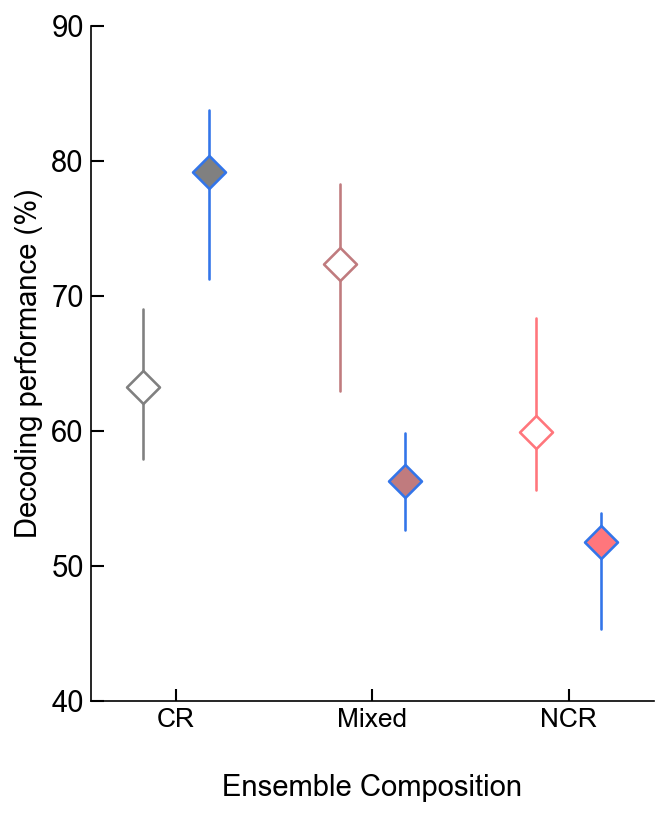

In [18]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax
def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax
fig,ax = make_axis_size(3.75, 4.5, left=.3, bottom=.3, right=0, top=0)
switch_offset = 1.5
pair_offset = 1

#Firing rate modulation graphs
NCR_COLORS = [CR_COLOR,MIX_COLOR,NCR_COLOR]
NCR_labels = ['CR','Mixed','NCR']
size=5
chosen_phases = ['pre_early','pre_late','pre_expert','post_early','post_late','post_expert']
bins = pd.IntervalIndex.from_tuples([(-0.01, 0.31), (0.49, 0.71), (0.79, 100.01)])

data = []
for chosen_phase in chosen_phases[4:5]:
    stim_df_com_control = stim_df[(stim_df.learning_phase==chosen_phase)]
    stim_df_com_control['NCR_ratio_binned'], _= pd.cut(stim_df_com_control['NCR_ratio'], bins=bins, retbins = True)
    clusters = stim_df_com_control['clust'].apply(ast.literal_eval)
    stim_df_ensemble_com_control = stim_df_com_control[[len(x)>1 for x in clusters]]

    stim_df_com_opsin = opto_df[(opto_df.learning_phase==chosen_phase)]
    stim_df_com_opsin['NCR_ratio_binned'], _= pd.cut(stim_df_com_opsin['NCR_ratio'], bins=bins, retbins = True)
    clusters = stim_df_com_opsin['clust'].apply(ast.literal_eval)
    stim_df_ensemble_com_opsin = stim_df_com_opsin[[len(x)>1 for x in clusters]]

    acc_temp = stim_df_ensemble_com_control[stim_df_ensemble_com_control['NCR_ratio_binned']==bins[0]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com_opsin[stim_df_ensemble_com_opsin['NCR_ratio_binned']==bins[0]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com_control[stim_df_ensemble_com_control['NCR_ratio_binned']==bins[1]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com_opsin[stim_df_ensemble_com_opsin['NCR_ratio_binned']==bins[1]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com_control[stim_df_ensemble_com_control['NCR_ratio_binned']==bins[2]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com_opsin[stim_df_ensemble_com_opsin['NCR_ratio_binned']==bins[2]]['accuracy'].tolist()
    data.append(acc_temp)


data = [np.abs(column) for column in data]

labels = ['Late']
numCon = 3
NCR_COLORS = [CR_COLOR,MIX_COLOR,NCR_COLOR]
NCR_labels = ['CR','Mixed','NCR']

x_list_plot = []
current_x = 0

for j in range(3):
    for m in range(2):
        x_list_plot.append(current_x)
        current_x = current_x+1
    current_x = current_x+pair_offset

#Plot summary
for idx,column in enumerate(data):    
    eye_color=GOOD_GREY
    
    r,g,b = mpl.colors.to_rgb(eye_color)
    h,l,s = colorsys.rgb_to_hls(r,g,b)
    border_color=colorsys.hls_to_rgb(h,l,s)
    border_color = 'k'
    summary_size=125
    summary_width=1.25
    
    X = np.ones(len(column))*(x_list_plot[idx])

    _,Y = ilep.violin(X,column,width=0.5,minjitter=0.05)
    X,_ = ilep.violin(X,np.log10(column),width=0.5,minjitter=0.05)
    colors = NCR_CR_cmap((Y-1)/5)

    mean = np.mean(column)
    sem = np.std(column, ddof=1) / np.sqrt(np.size(column))
    Q1, median, Q3 = (np.percentile(column, q) for q in [25, 50, 75])
    if idx%2!=0:
        facecolor = NCR_COLORS[idx//2%3]
        edgecolor = LASER_COLOR
        linecolor = LASER_COLOR
    else:
        
        facecolor = 'w'
        edgecolor = NCR_COLORS[idx//2%3]
        linecolor = NCR_COLORS[idx//2%3]
    ax.scatter([x_list_plot[idx]], [median], ec=edgecolor,fc= facecolor, s=summary_size,lw=summary_width, zorder=10,marker='D')
    ax.plot([x_list_plot[idx], x_list_plot[idx]], [Q1, Q3], c=linecolor, lw=summary_width, zorder=9, solid_capstyle='round')

ax.set_ylim([0.4,0.9])
ax.set_yticks([0.4,0.5,0.6,0.7,0.8,0.9])
ax.set_yticklabels(['40','50','60','70','80','90'])
ylab = ax.set_ylabel('Decoding performance (%)')

ax.set_xlim([x_list_plot[0]-0.8,x_list_plot[-1]+0.8])
ax.set_xticks([x_list_plot[1]-0.5,x_list_plot[3]-0.5,x_list_plot[5]-0.5])
ax.set_xticklabels(NCR_labels)
ax.set_xlim(ax.get_xlim())
xtick_pos_pre = ax.get_xticks()[1]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2.5*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre, Yval, 'Ensemble Composition', ha='center', va='bottom', fontsize=stdfont,color='k')

    
ax.fill_between(ax.get_xlim(),[ax.get_ylim()[0]]*2,[ax.get_ylim()[1]]*2,color='white',alpha=0.5,zorder=-5)


artists = [ylab,t1]
ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
# fig.savefig(os.path.join('..','..','Figures','Figure 3g.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')